<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/Set_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image:


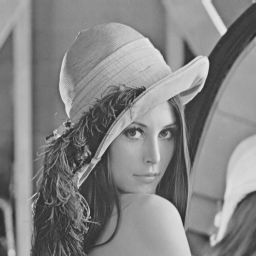

Degraded Image:


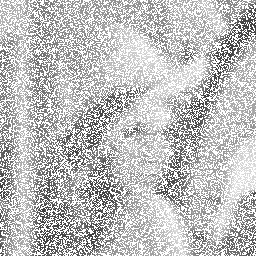

Restored Image (Direct Inverse Filtering):


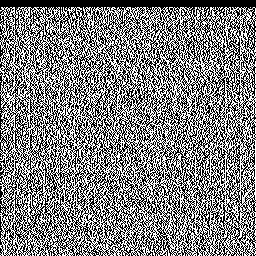

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

img = cv2.imread('lena_img.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Resize the image for consistency
    img = cv2.resize(img, (256, 256))
    rows, cols = img.shape

    psf_size = 15
    psf = np.zeros((psf_size, psf_size), np.float32)
    psf[int((psf_size - 1) / 2), :] = 1
    psf = psf / psf_size # Normalize

    degraded_img = cv2.filter2D(img, -1, psf, borderType=cv2.BORDER_REPLICATE)

    # Add some noise (e.g., Gaussian noise)
    mean = 0
    stddev = 10
    noise = np.random.normal(mean, stddev, degraded_img.shape).astype('uint8')
    degraded_img = cv2.add(degraded_img, noise) # Add noise


    # Direct Inverse Filtering

    # Get optimal DFT size for padding
    nrows = cv2.getOptimalDFTSize(rows + psf_size - 1)
    ncols = cv2.getOptimalDFTSize(cols + psf_size - 1)

    # Pad the degraded image and PSF to the optimal size
    padded_degraded_img = cv2.copyMakeBorder(degraded_img, 0, nrows - degraded_img.shape[0], 0, ncols - degraded_img.shape[1], cv2.BORDER_CONSTANT, value=0)
    padded_psf = cv2.copyMakeBorder(psf, 0, nrows - psf_size, 0, ncols - psf_size, cv2.BORDER_CONSTANT, value=0)


    # Perform DFT on the padded degraded image and PSF
    dft_degraded = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_psf = cv2.dft(np.float32(padded_psf), flags=cv2.DFT_COMPLEX_OUTPUT)

    epsilon = 1e-6
    dft_psf_magnitude_sq = dft_psf[:,:,0]**2 + dft_psf[:,:,1]**2
    inverse_dft_psf = dft_psf / (dft_psf_magnitude_sq[:,:,np.newaxis] + epsilon)


    restored_dft = np.zeros_like(dft_degraded)
    restored_dft[:,:,0] = dft_degraded[:,:,0] * inverse_dft_psf[:,:,0] - dft_degraded[:,:,1] * inverse_dft_psf[:,:,1]
    restored_dft[:,:,1] = dft_degraded[:,:,0] * inverse_dft_psf[:,:,1] + dft_degraded[:,:,1] * inverse_dft_psf[:,:,0]


    # Perform inverse DFT
    restored_img = cv2.idft(restored_dft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop the restored image back to original size
    restored_img = restored_img[0:rows, 0:cols]

    # Clip values to the valid range [0, 255] and convert to uint8
    restored_img = np.clip(restored_img, 0, 255).astype('uint8')


    # Display the results
    print("Original Image:")
    cv2_imshow(img)

    print("Degraded Image:")
    cv2_imshow(degraded_img)

    print("Restored Image (Direct Inverse Filtering):")
    cv2_imshow(restored_img)

Original Image:


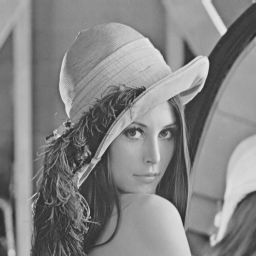

Degraded Image:


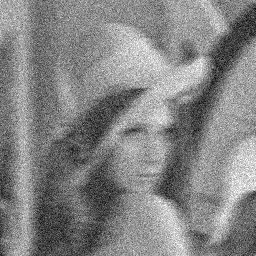

Restored Image (Wiener - Constant Ratio):


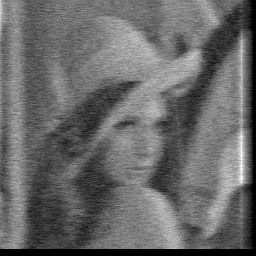

Restored Image (Wiener - Autocorrelation):


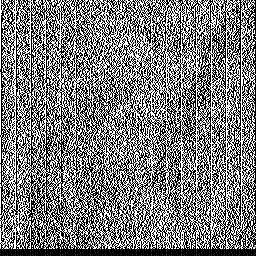

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Load a sample image (assuming 'lena_img.png' or 'image1.jpg' exists and resize it)
img = cv2.imread('lena_img.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Resize the image for consistency
    img = cv2.resize(img, (256, 256))
    rows, cols = img.shape

    psf_size = 15
    psf = np.zeros((psf_size, psf_size), np.float32)
    psf[int((psf_size - 1) / 2), :] = 1
    psf = psf / psf_size # Normalize

    degraded_img = cv2.filter2D(img, -1, psf, borderType=cv2.BORDER_REPLICATE)

    mean = 0
    stddev = 20
    noise = np.random.normal(mean, stddev, degraded_img.shape)
    degraded_img = cv2.add(degraded_img.astype(np.float32), noise.astype(np.float32))
    degraded_img = np.clip(degraded_img, 0, 255).astype('uint8')


    # Wiener Filtering

    # Get optimal DFT size for padding
    nrows = cv2.getOptimalDFTSize(rows + psf_size - 1)
    ncols = cv2.getOptimalDFTSize(cols + psf_size - 1)

    # Pad the degraded image and PSF to the optimal size
    padded_degraded_img = cv2.copyMakeBorder(degraded_img, 0, nrows - degraded_img.shape[0], 0, ncols - degraded_img.shape[1], cv2.BORDER_CONSTANT, value=0)
    padded_psf = cv2.copyMakeBorder(psf, 0, nrows - psf_size, 0, ncols - psf_size, cv2.BORDER_CONSTANT, value=0)


    # Perform DFT on the padded degraded image and PSF
    dft_degraded = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_psf = cv2.dft(np.float32(padded_psf), flags=cv2.DFT_COMPLEX_OUTPUT)

    # Calculate the magnitude squared of the PSF in the frequency domain
    dft_psf_magnitude_sq = dft_psf[:,:,0]**2 + dft_psf[:,:,1]**2

    noise_variance = stddev**2

    # Estimate image variance (variance of the original image)
    image_variance = np.var(img)

    # Calculate the constant ratio K
    K = noise_variance / image_variance if image_variance > 0 else 1e-6 # Avoid division by zero

    # Wiener filter in the frequency domain (constant ratio)
    wiener_filter_constant = dft_psf.copy()
    # Conjugate of H is H[:,:,0] - i * H[:,:,1]
    wiener_filter_constant[:,:,1] *= -1 # Take conjugate

    # Calculate the denominator: |H|^2 + K
    denominator_constant = dft_psf_magnitude_sq + K

    # Avoid division by zero
    denominator_constant[denominator_constant == 0] = 1e-6

    # Divide H* by (|H|^2 + K)
    wiener_filter_constant[:,:,0] /= denominator_constant
    wiener_filter_constant[:,:,1] /= denominator_constant

    # Multiply with the degraded image DFT
    restored_dft_constant = np.zeros_like(dft_degraded)
    restored_dft_constant[:,:,0] = dft_degraded[:,:,0] * wiener_filter_constant[:,:,0] - dft_degraded[:,:,1] * wiener_filter_constant[:,:,1]
    restored_dft_constant[:,:,1] = dft_degraded[:,:,0] * wiener_filter_constant[:,:,1] + dft_degraded[:,:,1] * wiener_filter_constant[:,:,0]


    # Perform inverse DFT for constant ratio Wiener filtering
    restored_img_constant = cv2.idft(restored_dft_constant, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop and clip
    restored_img_constant = restored_img_constant[0:rows, 0:cols]
    restored_img_constant = np.clip(restored_img_constant, 0, 255).astype('uint8')


    Sn = noise_variance # Assuming white noise

    dft_img = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT) # Using degraded image DFT for Sf approximation
    Sf = dft_img[:,:,0]**2 + dft_img[:,:,1]**2 + 1e-6 # Add epsilon to avoid division by zero


    # Calculate the ratio Sn(u,v) / Sf(u,v)
    noise_to_signal_ratio_freq = Sn / Sf

    # Wiener filter in the frequency domain (autocorrelation)
    wiener_filter_auto = dft_psf.copy()
    wiener_filter_auto[:,:,1] *= -1 # Take conjugate

    # Calculate the denominator: |H|^2 + Sn/Sf
    denominator_auto = dft_psf_magnitude_sq + noise_to_signal_ratio_freq

    # Avoid division by zero
    denominator_auto[denominator_auto == 0] = 1e-6

    # Divide H* by (|H|^2 + Sn/Sf)
    wiener_filter_auto[:,:,0] /= denominator_auto
    wiener_filter_auto[:,:,1] /= denominator_auto

    # Multiply with the degraded image DFT
    restored_dft_auto = np.zeros_like(dft_degraded)
    restored_dft_auto[:,:,0] = dft_degraded[:,:,0] * wiener_filter_auto[:,:,0] - dft_degraded[:,:,1] * wiener_filter_auto[:,:,1]
    restored_dft_auto[:,:,1] = dft_degraded[:,:,0] * wiener_filter_auto[:,:,1] + dft_degraded[:,:,1] * wiener_filter_auto[:,:,0]

    # Perform inverse DFT for autocorrelation Wiener filtering
    restored_img_auto = cv2.idft(restored_dft_auto, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop and clip
    restored_img_auto = restored_img_auto[0:rows, 0:cols]
    restored_img_auto = np.clip(restored_img_auto, 0, 255).astype('uint8')


    # Display the results
    print("Original Image:")
    cv2_imshow(img)

    print("Degraded Image:")
    cv2_imshow(degraded_img)

    print("Restored Image (Wiener - Constant Ratio):")
    cv2_imshow(restored_img_constant)

    print("Restored Image (Wiener - Autocorrelation):")
    cv2_imshow(restored_img_auto)

Original RGB Image:


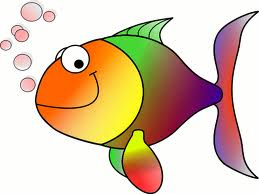

Hue Image:


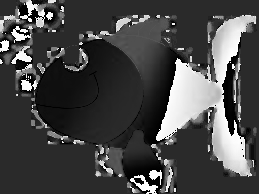

Saturation Image:


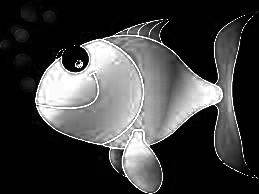

Intensity Image:


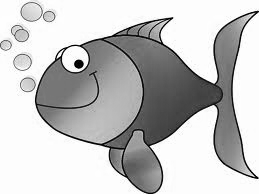

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Load an RGB image (using image1.jpg as an example, assuming it exists)
img_rgb = cv2.imread('image1.jpg', cv2.IMREAD_COLOR)

if img_rgb is None:
    print("Error: image1.jpg not found or could not be loaded.")
else:
    # Convert RGB to HSI manually (OpenCV doesn't have a direct HSI conversion)
    # Normalize pixel values to [0, 1]
    img_normalized = img_rgb.astype(np.float32) / 255.0
    B, G, R = cv2.split(img_normalized)

    # Calculate Intensity (I)
    I = (R + G + B) / 3.0

    # Calculate Saturation (S)
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3.0 * min_rgb) / (R + G + B + 1e-6) # Add epsilon to avoid division by zero
    S[R + G + B == 0] = 0 # Handle the case where R+G+B is zero

    # Calculate Hue (H)
    denominator = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-6
    theta = np.arccos(((R - G) + (R - B)) / (2 * denominator))

    H = np.degrees(theta)
    H[B > G] = 360 - H[B > G]

    H_display = (H / 360.0 * 255.0).astype('uint8')
    S_display = (S * 255.0).astype('uint8')
    I_display = (I * 255.0).astype('uint8')

    # Display the original and HSI channels
    print("Original RGB Image:")
    cv2_imshow(img_rgb)

    print("Hue Image:")
    cv2_imshow(H_display)

    print("Saturation Image:")
    cv2_imshow(S_display)

    print("Intensity Image:")
    cv2_imshow(I_display)

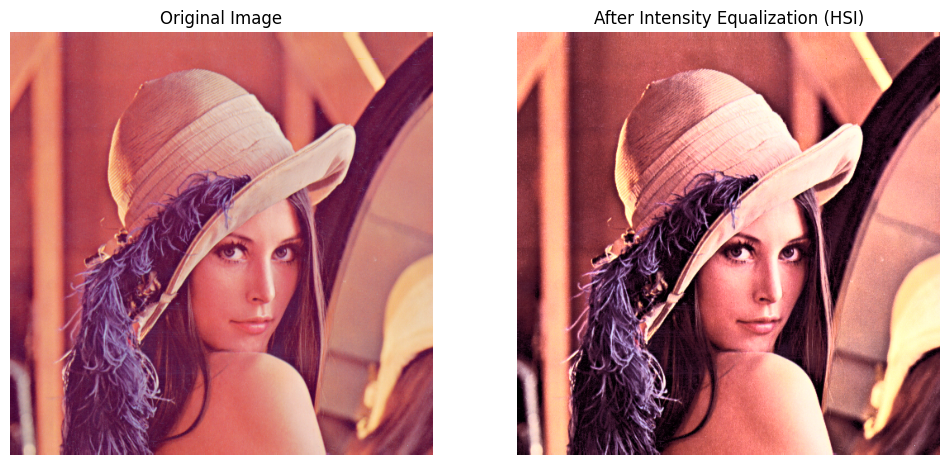

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rgb_to_hsi(img):
    # Normalize RGB to [0, 1]
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 2], img[:, :, 1], img[:, :, 0]
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B)*(G - B)) + 1e-6

    # Hue calculation
    theta = np.arccos(num / den)
    H = np.where(B <= G, theta, (2 * np.pi) - theta)
    H = H / (2 * np.pi)  # Normalize to [0,1]

    # Saturation calculation
    min_rgb = np.minimum(np.minimum(R, G), B)
    sum_rgb = R + G + B + 1e-6
    S = 1 - (3 * min_rgb / sum_rgb)

    # Intensity calculation
    I = sum_rgb / 3

    hsi = cv2.merge((H, S, I))
    return hsi


def hsi_to_rgb(hsi):
    H, S, I = cv2.split(hsi)
    H = H * 2 * np.pi  # back to radians

    R = np.zeros_like(H)
    G = np.zeros_like(H)
    B = np.zeros_like(H)

    # RG sector (0 ≤ H < 2π/3)
    idx = (H >= 0) & (H < 2*np.pi/3)
    B[idx] = I[idx] * (1 - S[idx])
    R[idx] = I[idx] * (1 + (S[idx] * np.cos(H[idx])) / (np.cos(np.pi/3 - H[idx])))
    G[idx] = 3 * I[idx] - (R[idx] + B[idx])

    # GB sector (2π/3 ≤ H < 4π/3)
    idx = (H >= 2*np.pi/3) & (H < 4*np.pi/3)
    H_tmp = H[idx] - 2*np.pi/3
    R[idx] = I[idx] * (1 - S[idx])
    G[idx] = I[idx] * (1 + (S[idx] * np.cos(H_tmp)) / (np.cos(np.pi/3 - H_tmp)))
    B[idx] = 3 * I[idx] - (R[idx] + G[idx])

    # BR sector (4π/3 ≤ H < 2π)
    idx = (H >= 4*np.pi/3) & (H < 2*np.pi)
    H_tmp = H[idx] - 4*np.pi/3
    G[idx] = I[idx] * (1 - S[idx])
    B[idx] = I[idx] * (1 + (S[idx] * np.cos(H_tmp)) / (np.cos(np.pi/3 - H_tmp)))
    R[idx] = 3 * I[idx] - (G[idx] + B[idx])

    rgb = cv2.merge((B, G, R))
    rgb = np.clip(rgb * 255, 0, 255).astype(np.uint8)
    return rgb


def equalize_intensity(img):
    # Convert RGB → HSI
    hsi = rgb_to_hsi(img)
    H, S, I = cv2.split(hsi)

    # Equalize intensity
    I_eq = cv2.equalizeHist((I * 255).astype(np.uint8))
    I_eq = I_eq.astype(np.float32) / 255.0

    # Merge back H, S, and equalized I
    hsi_eq = cv2.merge((H, S, I_eq))

    # Convert HSI → RGB
    rgb_eq = hsi_to_rgb(hsi_eq)

    return rgb_eq, hsi_eq


# ---- MAIN EXECUTION ----
# Load color image
img = cv2.imread('lena_img.png')  # Replace with your image path

# Perform histogram equalization on intensity
rgb_eq, hsi_eq = equalize_intensity(img)

# Display
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('After Intensity Equalization (HSI)')
plt.imshow(cv2.cvtColor(rgb_eq, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


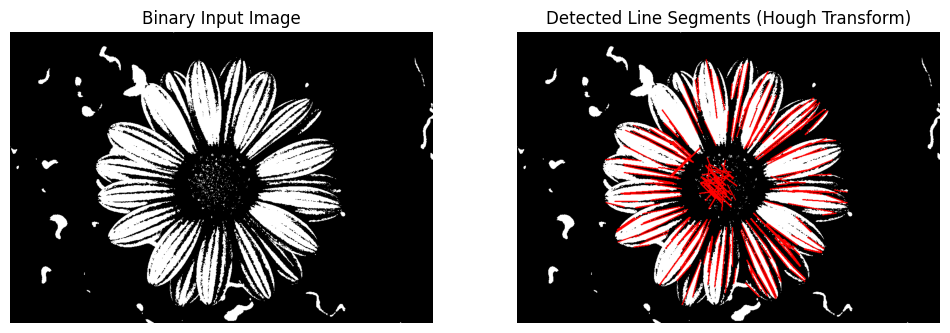

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image (grayscale)
img = cv2.imread('binary_image.png', cv2.IMREAD_GRAYSCALE)

# If it's not already binary, apply threshold
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Optionally detect edges (if image isn't clean binary)
edges = cv2.Canny(binary, 50, 150, apertureSize=3)

lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80,
                        minLineLength=30, maxLineGap=10)

# Convert to color image for visualization
color_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw detected lines
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(color_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Show results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Binary Input Image')
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Detected Line Segments (Hough Transform)')
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


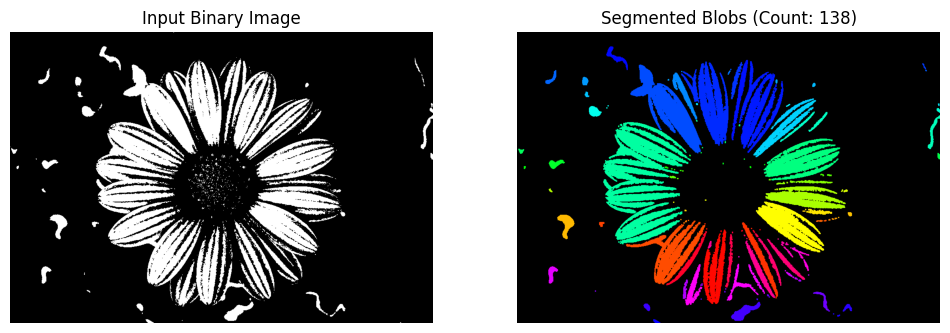

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load binary image (white blobs on black background)
binary = cv2.imread('binary_image.png', cv2.IMREAD_GRAYSCALE)

# Ensure it's binary (0 or 255)
_, binary = cv2.threshold(binary, 127, 255, cv2.THRESH_BINARY)

# Clean small noise (optional)
kernel = np.ones((3, 3), np.uint8)
binary_cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# Connected components labeling
num_labels, labels_im = cv2.connectedComponents(binary_cleaned)

# Colorize blobs
label_hue = np.uint8(179 * labels_im / np.max(labels_im))
blank_ch = 255 * np.ones_like(label_hue)
colored_labels = cv2.merge([label_hue, blank_ch, blank_ch])
colored_labels = cv2.cvtColor(colored_labels, cv2.COLOR_HSV2BGR)
colored_labels[label_hue == 0] = 0

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Input Binary Image')
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Segmented Blobs (Count: {num_labels - 1})')
plt.imshow(colored_labels)
plt.axis('off')
plt.show()


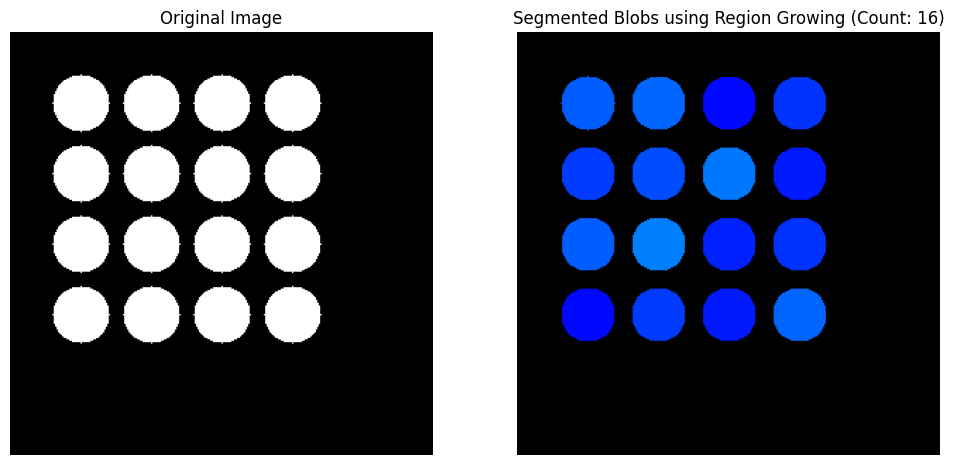

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

def region_growing(img, seeds, thresh=5):
    """
    img: grayscale image (2D)
    seeds: list of (x, y) coordinates as starting points
    thresh: intensity difference threshold for growing
    """
    h, w = img.shape
    segmented = np.zeros((h, w), np.uint8)
    label = 1

    # Directions for 8-neighbors
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                 (-1, -1), (-1, 1), (1, -1), (1, 1)]

    for seed in seeds:
        x, y = seed
        if segmented[x, y] != 0:
            continue

        region_intensity = int(img[x, y])
        queue = deque()
        queue.append((x, y))
        segmented[x, y] = label

        while queue:
            cx, cy = queue.popleft()
            for dx, dy in neighbors:
                nx, ny = cx + dx, cy + dy
                if 0 <= nx < h and 0 <= ny < w and segmented[nx, ny] == 0:
                    if abs(int(img[nx, ny]) - region_intensity) < thresh:
                        segmented[nx, ny] = label
                        queue.append((nx, ny))

        label += 1

    return segmented, label - 1


# ---- MAIN EXECUTION ----
# Load grayscale image
img = cv2.imread('binary_image.png', cv2.IMREAD_GRAYSCALE)

# Optional: smooth a bit to reduce noise
img_smooth = cv2.GaussianBlur(img, (3, 3), 0)

# Choose seeds automatically (simple heuristic)
# Seeds are picked where pixel intensity > threshold (bright blobs)
seed_points = np.argwhere(img_smooth > 180)
seed_points = [tuple(pt) for pt in seed_points[::500]]  # sample every 500th pixel

# Apply region growing
segmented, num_regions = region_growing(img_smooth, seed_points, thresh=15)

# Colorize segmented regions
label_hue = np.uint8(179 * segmented / np.max(segmented))
blank_ch = 255 * np.ones_like(label_hue)
colored = cv2.merge([label_hue, blank_ch, blank_ch])
colored = cv2.cvtColor(colored, cv2.COLOR_HSV2BGR)
colored[label_hue == 0] = 0

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Segmented Blobs using Region Growing (Count: {num_regions})')
plt.imshow(colored)
plt.axis('off')
plt.show()


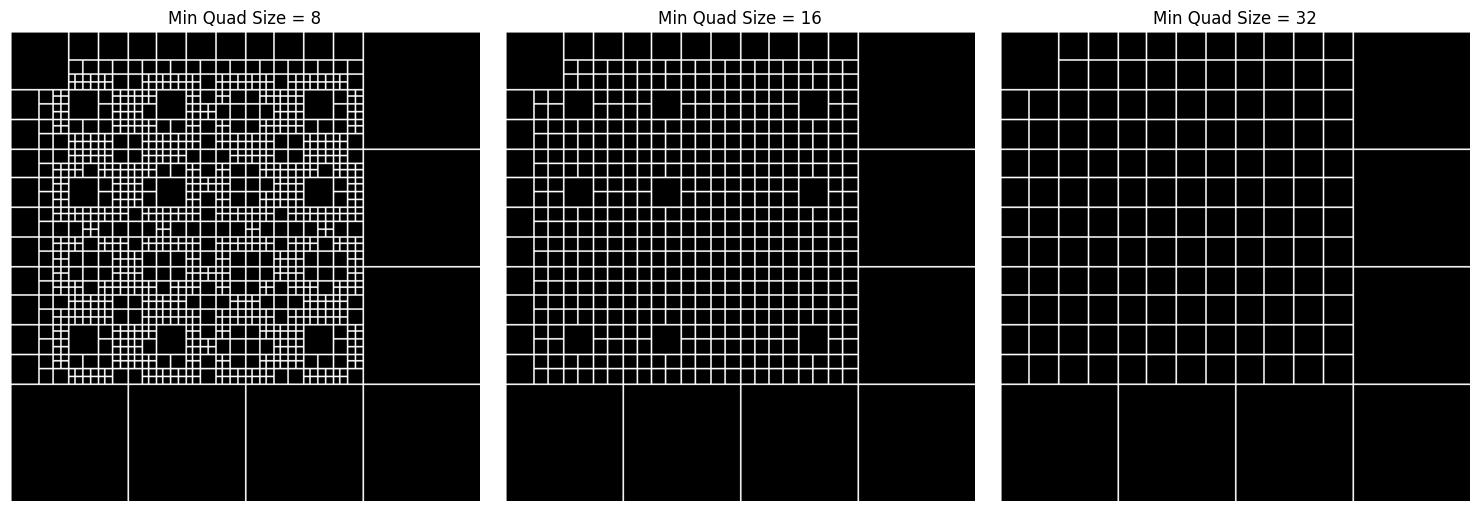

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to check homogeneity (variance-based)
def homogeneous(region, threshold=10):
    return np.std(region) < threshold

# Recursive splitting function
def split(image, min_size):
    h, w = image.shape
    if h <= min_size or w <= min_size or homogeneous(image):
        return [image]

    mid_h, mid_w = h // 2, w // 2
    quadrants = [
        image[0:mid_h, 0:mid_w],
        image[0:mid_h, mid_w:w],
        image[mid_h:h, 0:mid_w],
        image[mid_h:h, mid_w:w]
    ]
    result = []
    for q in quadrants:
        result.extend(split(q, min_size))
    return result

# Merge-like visualization (not full region merging)
def visualize_split(image, min_size):
    mask = np.zeros_like(image)
    def draw_rect(x, y, w, h):
        cv2.rectangle(mask, (x, y), (x + w, y + h), 255, 1)

    def recursive_split(img, x, y, min_size):
        h, w = img.shape
        if h <= min_size or w <= min_size or homogeneous(img):
            draw_rect(x, y, w, h)
            return
        mid_h, mid_w = h // 2, w // 2
        recursive_split(img[0:mid_h, 0:mid_w], x, y, min_size)
        recursive_split(img[0:mid_h, mid_w:w], x + mid_w, y, min_size)
        recursive_split(img[mid_h:h, 0:mid_w], x, y + mid_h, min_size)
        recursive_split(img[mid_h:h, mid_w:w], x + mid_w, y + mid_h, min_size)

    recursive_split(image, 0, 0, min_size)
    return mask

# Read grayscale image
img = cv2.imread('binary_image.png', cv2.IMREAD_GRAYSCALE)

# Try different minimum sizes
sizes = [8, 16, 32]
plt.figure(figsize=(15, 5))
for i, s in enumerate(sizes):
    mask = visualize_split(img, s)
    plt.subplot(1, 3, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Min Quad Size = {s}')
    plt.axis('off')
plt.tight_layout()
plt.show()


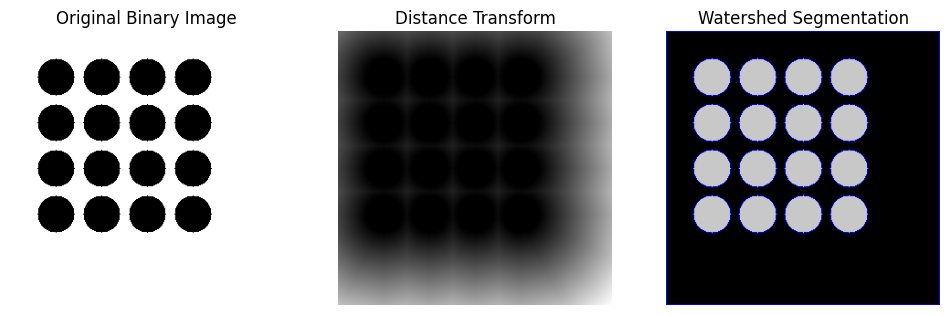

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('binary_image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to binary
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Sure foreground area (using distance transform)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels (so that background is not 0, but 1)
markers = markers + 1

# Mark unknown regions with zero
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]  # Boundary in red

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Original Binary Image")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Watershed Segmentation")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
